In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

### Step 1: Understanding the dataset

The dataset contains Spotify tracks with metadata, audio features and popularity scores.

Before choosing visualizations and machine learning methods,
we first inspect the dataset structure, data types and basic summary statistics:

In [20]:
df = pd.read_csv("../data/spotify_cleaned_unique_tracks.csv")

df.head()
df.info()
df.describe()

df.shape
df.isna().sum()
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          89740 non-null  str    
 1   artists           89740 non-null  str    
 2   album_name        89740 non-null  str    
 3   track_name        89740 non-null  str    
 4   popularity        89740 non-null  int64  
 5   duration_ms       89740 non-null  int64  
 6   explicit          89740 non-null  bool   
 7   danceability      89740 non-null  float64
 8   energy            89740 non-null  float64
 9   key               89740 non-null  int64  
 10  loudness          89740 non-null  float64
 11  mode              89740 non-null  int64  
 12  speechiness       89740 non-null  float64
 13  acousticness      89740 non-null  float64
 14  instrumentalness  89740 non-null  float64
 15  liveness          89740 non-null  float64
 16  valence           89740 non-null  float64
 17  temp

track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature      float64
track_genre             str
duration_min        float64
dtype: object

### Remove missing values:

In [21]:
df_clean = df.dropna(subset=["tempo", "time_signature"]).copy()

df_clean.shape

(89578, 21)

### Control after removal:

In [22]:
df_clean.isna().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
duration_min        0
dtype: int64

### Step 2: Handling missing values

The dataset contains 89,740 tracks. Only a small number of missing values were found in `tempo` and `time_signature`.

Since the number of missing values is very small compared to the full dataset, we removed those rows instead of filling them with estimated values.

### Chosing core variables:

In [36]:
features = [
    "popularity",
    "duration_min",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

### Step 3: Popularity Distribution

We start by analyzing the distribution of song popularity.

This helps us understand whether hit songs are rare and how popularity is spread across tracks.

This is important for our case, since we are trying to identify what makes a song stand out as a hit:

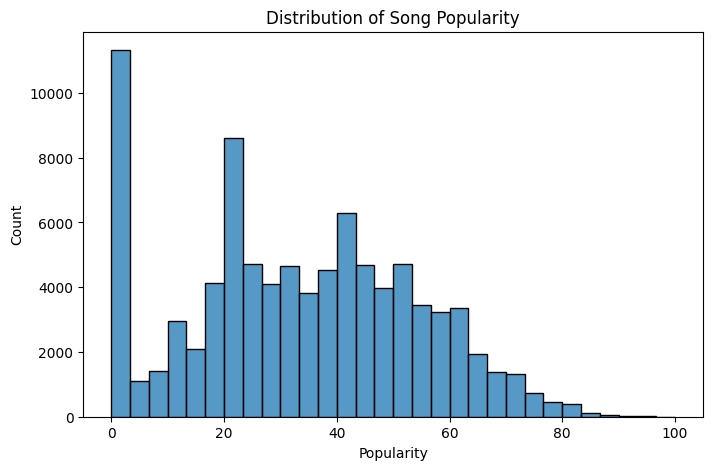

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["popularity"], bins=30)
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

### -> Interpretation of Popularity Distribution

The distribution of song popularity is highly skewed, with a large number of tracks having very low popularity and only a small number reaching high popularity.

This indicates that hit songs are relatively rare and that most songs do not achieve widespread success.

For our case, this suggests that becoming a hit requires specific characteristics that distinguish a song from the majority.

### Step 5: Popularity vs Danceability
- Does a hitsong have high danceability?  
Scatterplot:

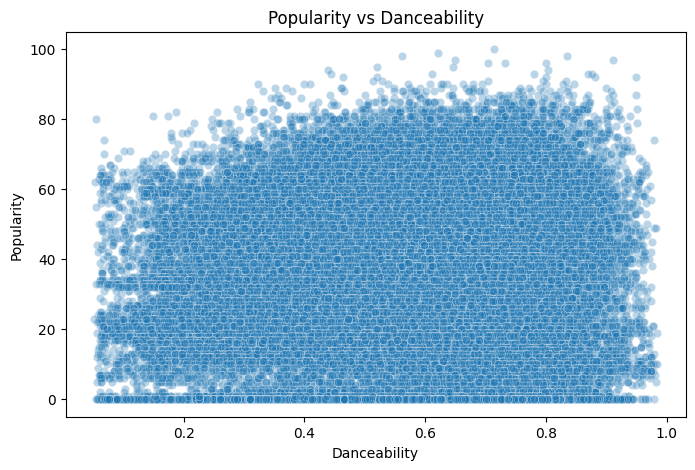

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="danceability", y="popularity", data=df_clean, alpha=0.3)
plt.title("Popularity vs Danceability")
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.show()

### -> Interpretation: Popularity vs Danceability

The scatterplot shows no strong linear relationship between danceability and popularity.

However, we observe that highly popular songs tend to have moderate to high danceability, while very low danceability values are less represented among top hits.

This suggests that danceability may be a contributing factor, but not a decisive one in creating a hit song.

### Step 6: Popularity vs Energy
- Does a hitsong have high energy?  
Scatterplot:

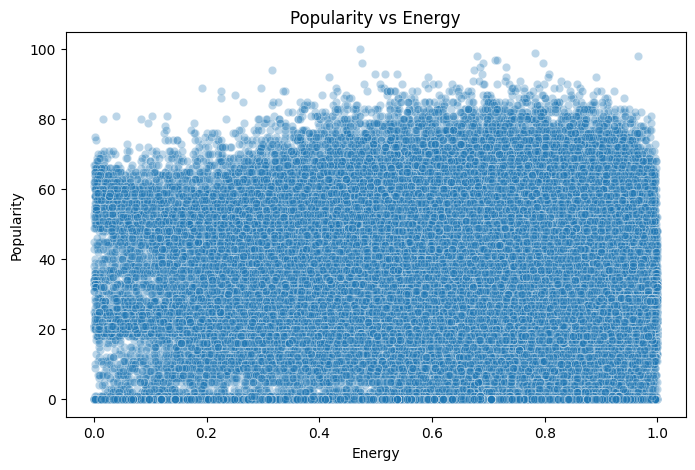

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="energy", y="popularity", data=df_clean, alpha=0.3)
plt.title("Popularity vs Energy")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.show()

### -> Interpretation: Popularity vs Energy

The scatterplot shows no strong linear relationship between energy and popularity.

However, compared to danceability, we observe a clearer tendency: highly popular songs are more frequently found at medium to high energy levels, while very low-energy songs are less common among top hits.

This suggests that energy may play a more important role than danceability in defining a hit song, although it is not a decisive factor on its own.

### Step 7: Popolarity vs Valence
- Does a hit song sound happier?  
Scatterplot:

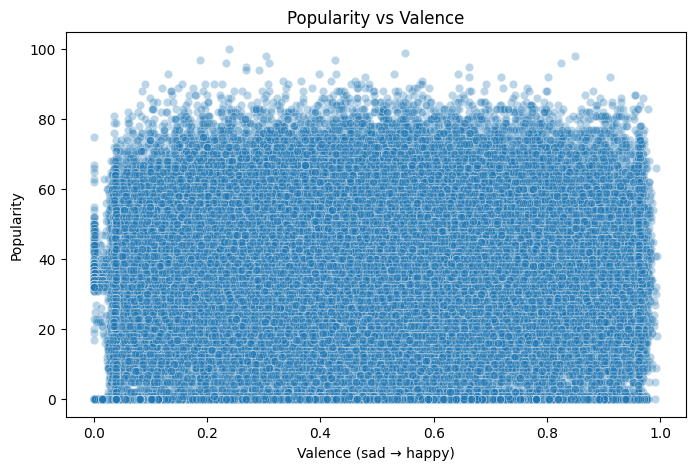

In [41]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="valence", y="popularity", data=df_clean, alpha=0.3)
plt.title("Popularity vs Valence")
plt.xlabel("Valence (sad → happy)")
plt.ylabel("Popularity")
plt.show()

### -> Interpretation: Popularity vs Valence

The scatterplot shows no clear relationship between valence and popularity.

Highly popular songs are found across the entire spectrum, from low valence (sad) to high valence (happy).

This suggests that emotional tone alone does not determine whether a song becomes a hit.

### Step 8: Popularity vs Tempo
- Does hit song have a specific tempo (BPM)  
Scatterplot:

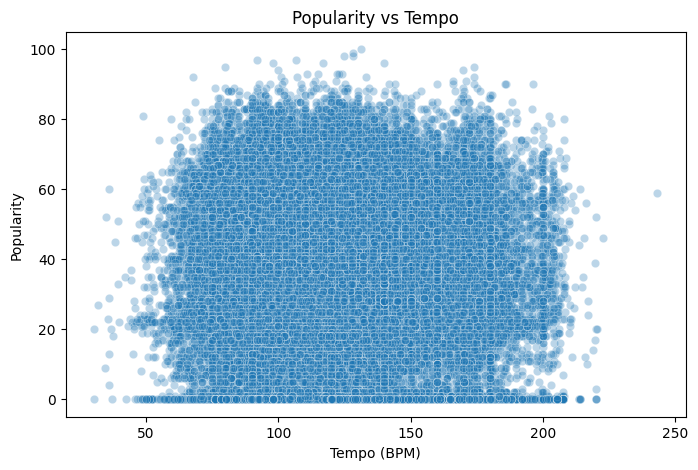

In [42]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="tempo", y="popularity", data=df_clean, alpha=0.3)
plt.title("Popularity vs Tempo")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Popularity")
plt.show()

### -> Interpretation: Popularity vs Tempo

The scatterplot shows no strong linear relationship between tempo and popularity.

However, we observe that highly popular songs are more frequently found within a moderate tempo range, roughly between 90 and 140 BPM.

Very slow or very fast songs appear less frequently among top hits.

This suggests that tempo may play a role in defining a hit song, particularly in avoiding extreme values.

### Step 9: Energy + Danceability
- Is there a "sweet spot" for hit songs when we combine variables?  
Scatterplot:

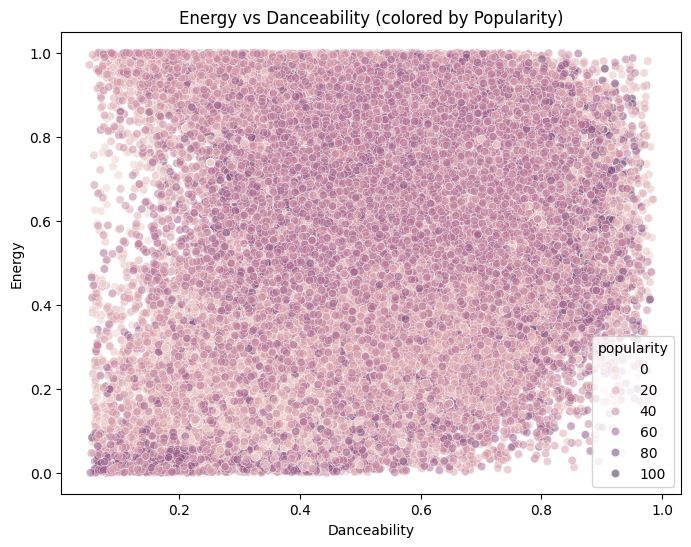

In [43]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="danceability",
    y="energy",
    hue="popularity",
    data=df_clean,
    alpha=0.5
)

plt.title("Energy vs Danceability (colored by Popularity)")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.show()

-> The combined scatterplot of energy and danceability does not show a clear concentration of highly popular songs.

This suggests that no simple combination of these two variables alone defines a hit song.

### Step 9.1: Hits vs non-hits

In [44]:
df_clean["is_hit"] = df_clean["popularity"] >= 70

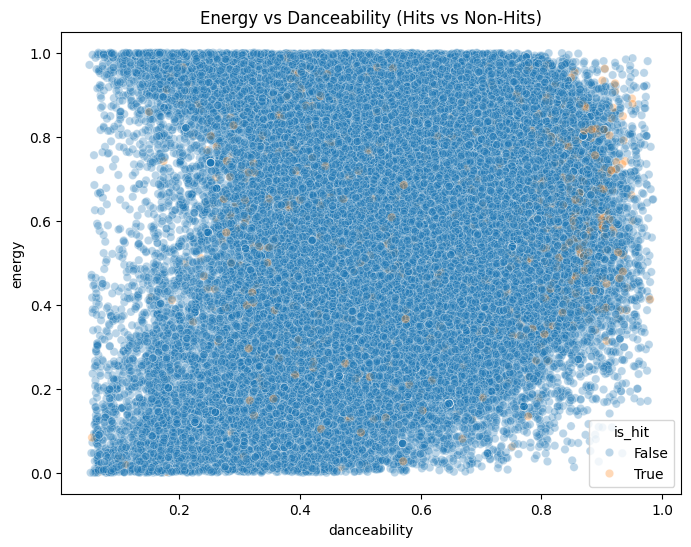

In [45]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="danceability",
    y="energy",
    hue="is_hit",
    data=df_clean,
    alpha=0.3
)

plt.title("Energy vs Danceability (Hits vs Non-Hits)")
plt.show()

### -> Combined Interpretation: Energy and Danceability

The comparison between hits and non-hits does not reveal a clearly defined cluster of hit songs.

However, we observe a tendency for hit songs to appear more frequently in regions with moderate to high energy and danceability.

Songs with both low energy and low danceability are rarely highly popular.

This suggests that while these features alone do not define a hit, they contribute to increasing the likelihood of success.

In [47]:
features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo"
]

X = df_clean[features]

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [49]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [50]:
df_clean["cluster"] = clusters

### Step 10: What type of songs have the best chanse to become hit songs?

In [51]:
df_clean.groupby("cluster")["popularity"].mean().sort_values(ascending=False)

cluster
0    34.235969
3    33.630469
1    33.365871
2    30.425470
Name: popularity, dtype: float64

### -> Cluster-Based Interpretation

The comparison of average popularity across clusters shows only small differences between most groups, suggesting that there is no single dominant formula for a hit song.

However, one cluster stands out: the low-energy, acoustic cluster has noticeably lower average popularity.

This suggests that while hit songs can vary in style, they are less likely to be slow, acoustic, and low-energy.

Instead, songs with higher energy and danceability tend to perform better overall.

### Popularity vs Energy
Boxplot:

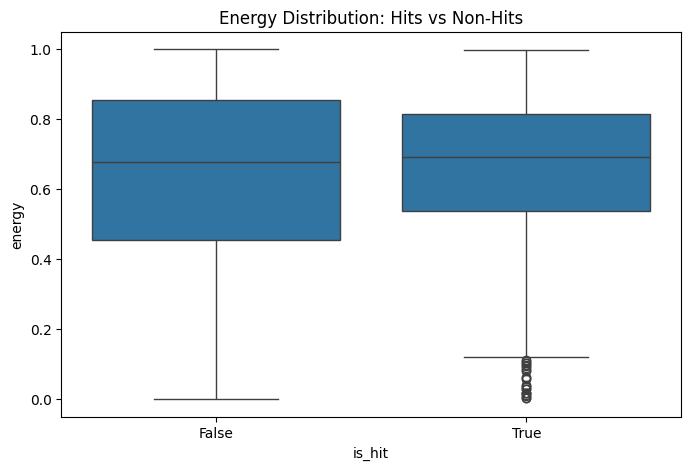

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_hit", y="energy", data=df_clean)
plt.title("Energy Distribution: Hits vs Non-Hits")
plt.show()

### Popularity vs Danceability
Boxplot:

<Axes: xlabel='is_hit', ylabel='danceability'>

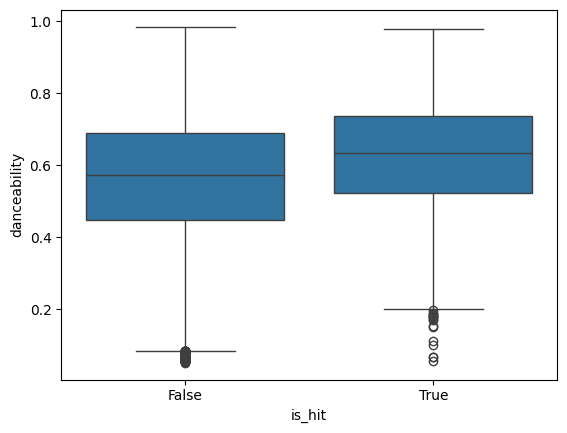

In [53]:
sns.boxplot(x="is_hit", y="danceability", data=df_clean)

### Popularity vs Tempo
Boxplot:

<Axes: xlabel='is_hit', ylabel='tempo'>

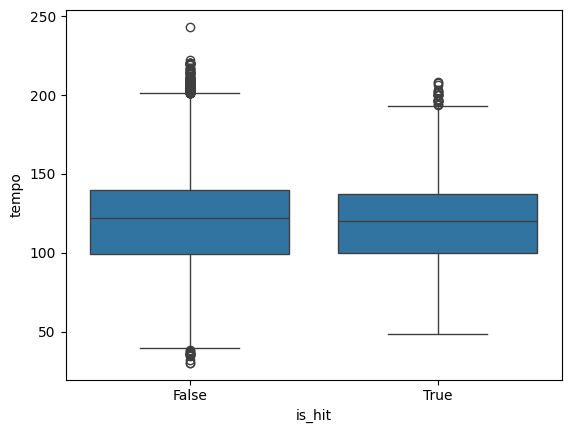

In [54]:
sns.boxplot(x="is_hit", y="tempo", data=df_clean)

### Popularity vs Energy
Violinplot:

<Axes: xlabel='is_hit', ylabel='energy'>

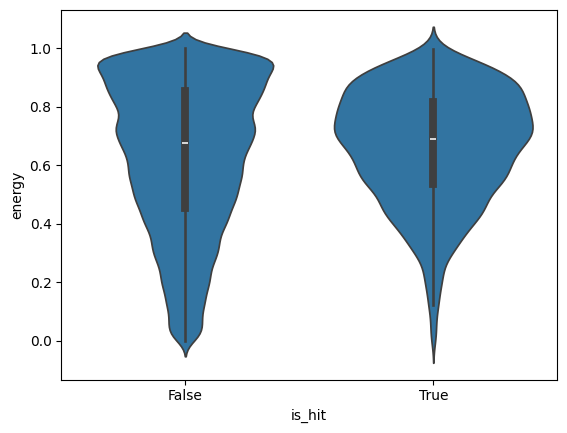

In [55]:
sns.violinplot(x="is_hit", y="energy", data=df_clean)